# Comparing enrichment-score methods on scRNA-seq

`ov.es` ships GPU-accelerated implementations of 11 enrichment-score (ES) algorithms. They all expose the same `(adata, signatures, engine)` API, so you can swap one for another by changing a single line. This tutorial walks through every method on the same gene set, shows the math behind it, and visualises the score on the UMAP.

We use the same dataset and pathways as the [AUCell tutorial](../t_aucell.ipynb).

## Part.1 Data preprocess

In [1]:
import omicverse as ov
ov.style()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()
adata

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [3]:
adata.var['robust'] = True
adata = ov.pp.preprocess(adata, target_sum=1e4)

🔍 [2026-05-17 21:33:55] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.24s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 16,426 total (12.2%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.40 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

## Part.2 Gene sets

Load the GO Biological Process collection and pick a representative pathway.

In [4]:
pathway_dict = ov.utils.geneset_prepare(
    'genesets/GO_Biological_Process_2021.txt', organism='Mouse',
)

In [5]:
geneset_name = 'response to vitamin (GO:0033273)'
signatures = {geneset_name: pathway_dict[geneset_name]}

## ov.es.aucell

**AUCell** uses the area under the recovery curve to measure how early signature genes appear in the per-cell expression ranking.

$$ES_{i, F} = \int_0^1 R_{i, F}(r)\, dr$$

where $R_{i, F}(r)$ is the proportion of signature $F$ genes recovered in the top-$r$ fraction of cell $i$'s ranking. AUCell is *rank-based* — it only cares about the order of genes, not their absolute expression.

Reference: [Aibar et al., Nat Methods (2017)](https://doi.org/10.1038/nmeth.4463).

In [6]:
ov.es.aucell(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.aucell ────────────────────────────────────────────╮
│  Duration: 0.5998s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_aucell (dataframe, 3696x1)                     │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


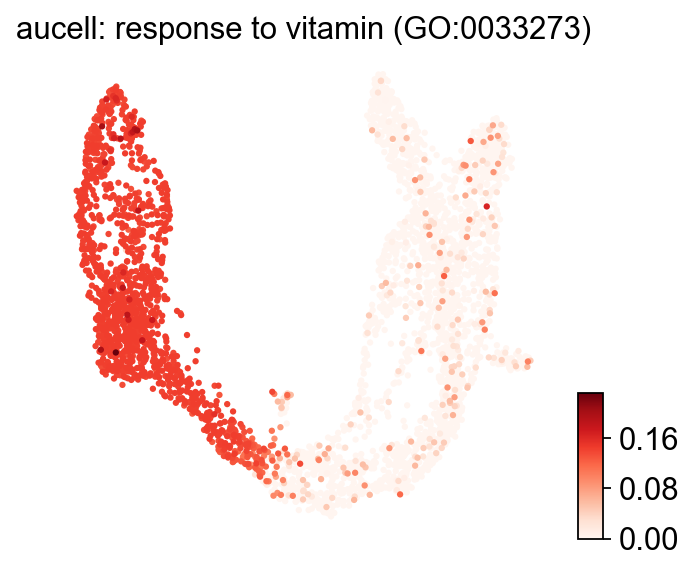

In [7]:
adata.obs[f'aucell: {geneset_name}'] = adata.obsm['score_aucell'][geneset_name].values
ov.pl.umap(adata, color=f'aucell: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.gsea

**GSEA** ranks features and walks down the list, adding to a running sum when a feature is in the signature and subtracting otherwise. The enrichment score is the maximum positive deviation of that walk.

$$\delta(F, i) = \begin{cases} \frac{|r_i|}{\sum_{j \in F} |r_j|} & i \in F \\ -\frac{1}{N-k} & i \notin F \end{cases}, \quad ES = \max_i \sum_{j \le i} \delta(F, j)$$

We pass `times=1` so the GPU kernel only computes the deterministic ES (permutation-based p-values fall back to CPU).

Reference: [Subramanian et al., PNAS (2005)](https://doi.org/10.1073/pnas.0506580102).

In [8]:
ov.es.gsea(adata, signatures=signatures, tmin=3, engine='gpu', times=1)


╭─ SUMMARY: ov.es.gsea ──────────────────────────────────────────────╮
│  Duration: 0.3324s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_gsea (dataframe, 3696x1)                        │
│           │ ✚ score_gsea (dataframe, 3696x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


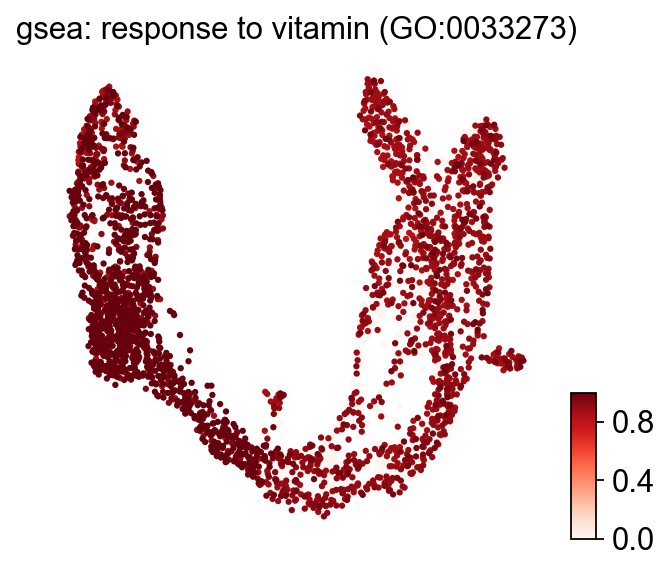

In [9]:
adata.obs[f'gsea: {geneset_name}'] = adata.obsm['score_gsea'][geneset_name].values
ov.pl.umap(adata, color=f'gsea: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.gsva

**GSVA** first transforms each gene's expression to a non-parametric CDF (Gaussian or Poisson kernel), then runs a Kolmogorov–Smirnov-style random walk over the ranks. Unlike GSEA, it does this *per cell*, producing a sample-level enrichment that's amenable to downstream differential analysis.

$$ES = \max_i L_i + \min_i L_i$$

where $L$ is the cumulative running statistic.

Reference: [Hänzelmann et al., BMC Bioinf (2013)](https://doi.org/10.1186/1471-2105-14-7).

In [10]:
ov.es.gsva(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.gsva ──────────────────────────────────────────────╮
│  Duration: 3.8699s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_gsva (dataframe, 3696x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


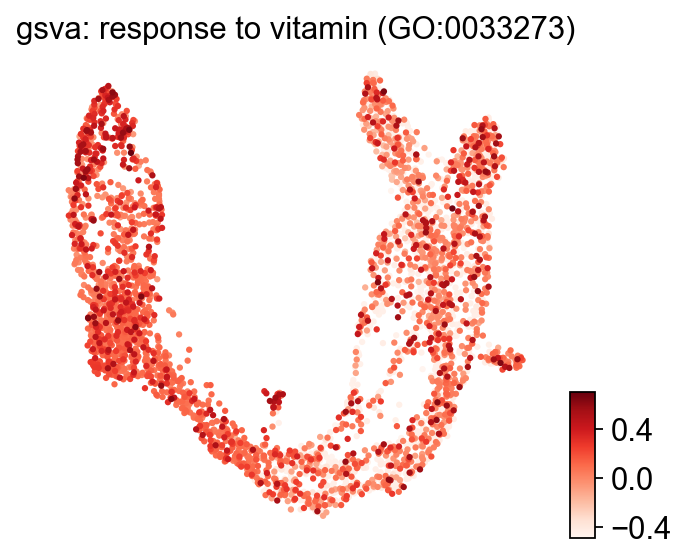

In [11]:
adata.obs[f'gsva: {geneset_name}'] = adata.obsm['score_gsva'][geneset_name].values
ov.pl.umap(adata, color=f'gsva: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.ora

**ORA** (Over-Representation Analysis) tests, with the hypergeometric distribution, whether the signature is over-represented in the genes that pass a per-cell significance threshold. The score is the log-odds ratio.

$$ES = \log\frac{a\,d}{b\,c}, \quad p = P(X \ge a)$$

where $(a, b, c, d)$ are the 2×2 contingency entries and $X$ is hypergeometric.

Reference: [Fisher, J R Stat Soc (1922)](https://doi.org/10.2307/2340521).

In [12]:
ov.es.ora(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.ora ───────────────────────────────────────────────╮
│  Duration: 0.293s                                                  │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ora (dataframe, 3696x1)                         │
│           │ ✚ score_ora (dataframe, 3696x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


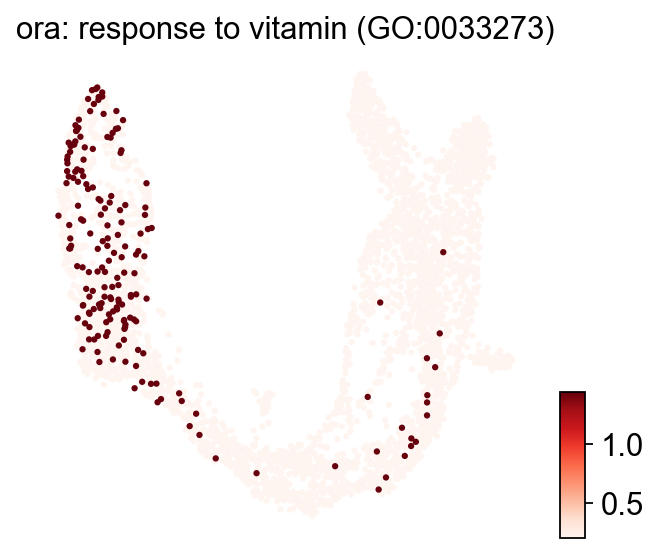

In [13]:
adata.obs[f'ora: {geneset_name}'] = adata.obsm['score_ora'][geneset_name].values
ov.pl.umap(adata, color=f'ora: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.ulm

**ULM** (Univariate Linear Model) fits one regression per signature: features become observations, expression in a cell becomes the response, and the signature weights become the regressor. The score is the slope's t-statistic.

$$y_g = \beta_0 + \beta_1 w_g + \varepsilon, \quad ES = t(\hat{\beta}_1)$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [14]:
ov.es.ulm(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.ulm ───────────────────────────────────────────────╮
│  Duration: 0.2721s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ulm (dataframe, 3696x1)                         │
│           │ ✚ score_ulm (dataframe, 3696x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


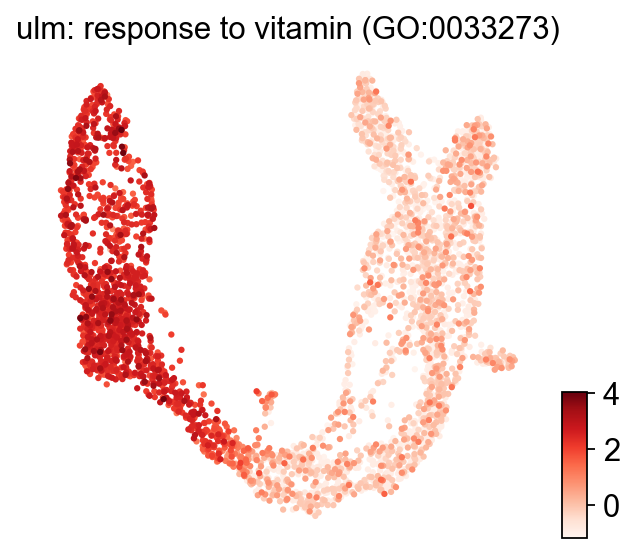

In [15]:
adata.obs[f'ulm: {geneset_name}'] = adata.obsm['score_ulm'][geneset_name].values
ov.pl.umap(adata, color=f'ulm: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.mlm

**MLM** (Multivariate Linear Model) is the joint version of ULM: one regression per cell, all signatures as covariates simultaneously. The score for signature $j$ is the t-statistic of its coefficient — useful when signatures overlap because the joint fit deconfounds shared genes.

$$y_g = \beta_0 + \sum_j \beta_j W_{g, j} + \varepsilon$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [16]:
ov.es.mlm(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.mlm ───────────────────────────────────────────────╮
│  Duration: 0.3006s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_mlm (dataframe, 3696x1)                         │
│           │ ✚ score_mlm (dataframe, 3696x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


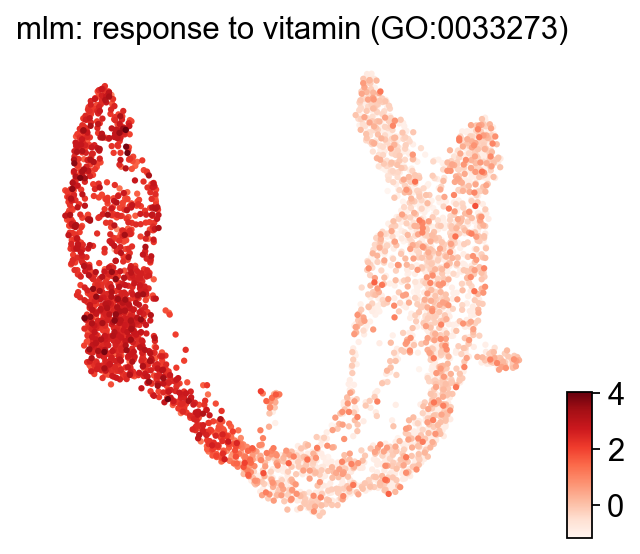

In [17]:
adata.obs[f'mlm: {geneset_name}'] = adata.obsm['score_mlm'][geneset_name].values
ov.pl.umap(adata, color=f'mlm: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.waggr

**WAGGR** (Weighted Aggregate) is the simplest scorer: a weighted sum (`wsum`) or weighted mean (`wmean`) of signature-gene expression. Fast, interpretable, and the linear baseline against which the more elaborate methods are typically benchmarked.

$$ES = \sum_g w_g\, x_g \quad \text{or} \quad ES = \frac{\sum_g w_g\, x_g}{\sum_g |w_g|}$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [18]:
ov.es.waggr(adata, signatures=signatures, tmin=3, engine='gpu', times=1)


╭─ SUMMARY: ov.es.waggr ─────────────────────────────────────────────╮
│  Duration: 0.2709s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_waggr (dataframe, 3696x1)                       │
│           │ ✚ score_waggr (dataframe, 3696x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


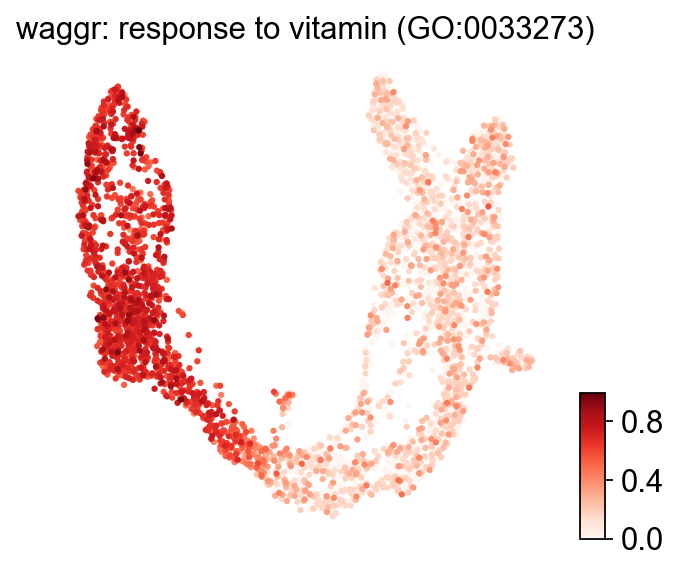

In [19]:
adata.obs[f'waggr: {geneset_name}'] = adata.obsm['score_waggr'][geneset_name].values
ov.pl.umap(adata, color=f'waggr: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.zscore

**Z-score** standardises each cell's signature mean against an empirical null built from all other genes in the same cell.

$$ES = \frac{\bar{x}_F - \mu}{\sigma}\sqrt{|F|}$$

where $\mu, \sigma$ are the per-cell mean and standard deviation across **all** features.

Reference: [Holland et al., Nat Commun (2021)](https://doi.org/10.1038/s41467-021-21211-6).

In [20]:
ov.es.zscore(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.zscore ────────────────────────────────────────────╮
│  Duration: 0.272s                                                  │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_zscore (dataframe, 3696x1)                      │
│           │ ✚ score_zscore (dataframe, 3696x1)                     │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


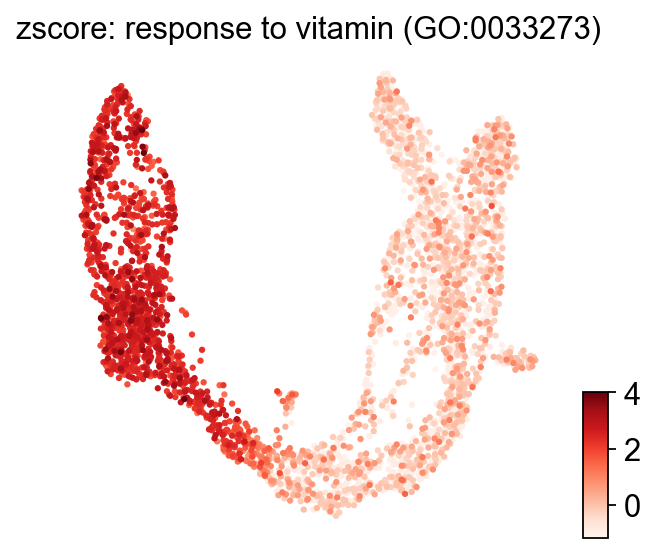

In [21]:
adata.obs[f'zscore: {geneset_name}'] = adata.obsm['score_zscore'][geneset_name].values
ov.pl.umap(adata, color=f'zscore: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.viper

**VIPER** treats the signature as a regulon: it computes an *analytical Rank-based Enrichment Analysis* (aREA) score that combines a magnitude term and a directional term, then optionally refines it with a pleiotropy correction that down-weights overlapping regulons.

$$ES = S_3 \sqrt{\sum_i l_i^2}, \quad S_3 = \begin{cases} (|S_2| + S_1)\, \text{sgn}(S_2) & S_1 > 0 \\ S_2 & S_1 \le 0 \end{cases}$$

Reference: [Alvarez et al., Nat Genet (2016)](https://doi.org/10.1038/ng.3593).

In [22]:
ov.es.viper(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.viper ─────────────────────────────────────────────╮
│  Duration: 0.5143s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_viper (dataframe, 3696x1)                       │
│           │ ✚ score_viper (dataframe, 3696x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


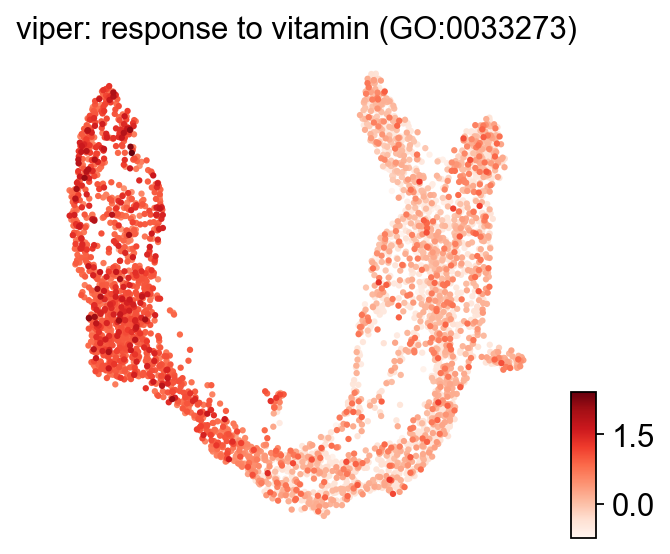

In [23]:
adata.obs[f'viper: {geneset_name}'] = adata.obsm['score_viper'][geneset_name].values
ov.pl.umap(adata, color=f'viper: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.mdt

**MDT** (Multivariate Decision Tree) fits one gradient-boosted decision tree per cell with all signatures as covariates and the cell's expression as the response. The score for each signature is its normalised feature importance (sum of split gains) in the trained model.

$$ES_j = \frac{\sum_{\text{splits on } j} \text{gain}}{\sum_{j'} \sum_{\text{splits on } j'} \text{gain}}$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [24]:
ov.es.mdt(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.mdt ───────────────────────────────────────────────╮
│  Duration: 17.0291s                                                │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_mdt (dataframe, 3696x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


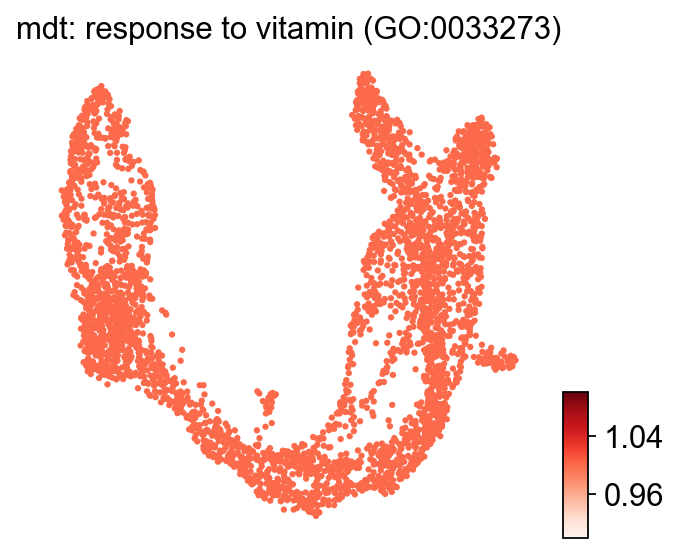

In [25]:
adata.obs[f'mdt: {geneset_name}'] = adata.obsm['score_mdt'][geneset_name].values
ov.pl.umap(adata, color=f'mdt: {geneset_name}', cmap='Reds', frameon=False)

## ov.es.udt

**UDT** (Univariate Decision Tree) is the per-signature counterpart of MDT: for each cell × signature pair, fit a univariate gradient-boosted tree using that single signature as the regressor and report the coefficient of determination $R^2$.

$$ES = R^2 = 1 - \frac{\sum_g (y_g - \hat{y}_g)^2}{\sum_g (y_g - \bar{y})^2}$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [26]:
ov.es.udt(adata, signatures=signatures, tmin=3, engine='gpu')


╭─ SUMMARY: ov.es.udt ───────────────────────────────────────────────╮
│  Duration: 1.8516s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_udt (dataframe, 3696x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


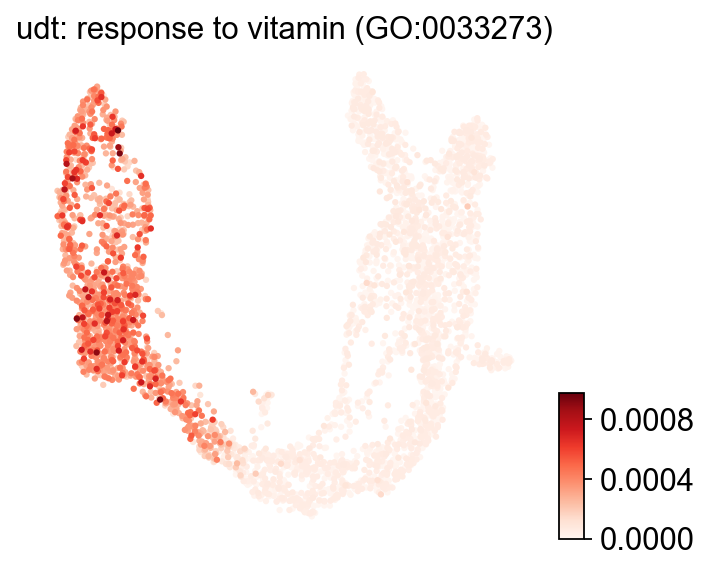

In [27]:
adata.obs[f'udt: {geneset_name}'] = adata.obsm['score_udt'][geneset_name].values
ov.pl.umap(adata, color=f'udt: {geneset_name}', cmap='Reds', frameon=False)

## Side-by-side comparison

Plot all eleven methods on one figure so the differences (and similarities) jump out.

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


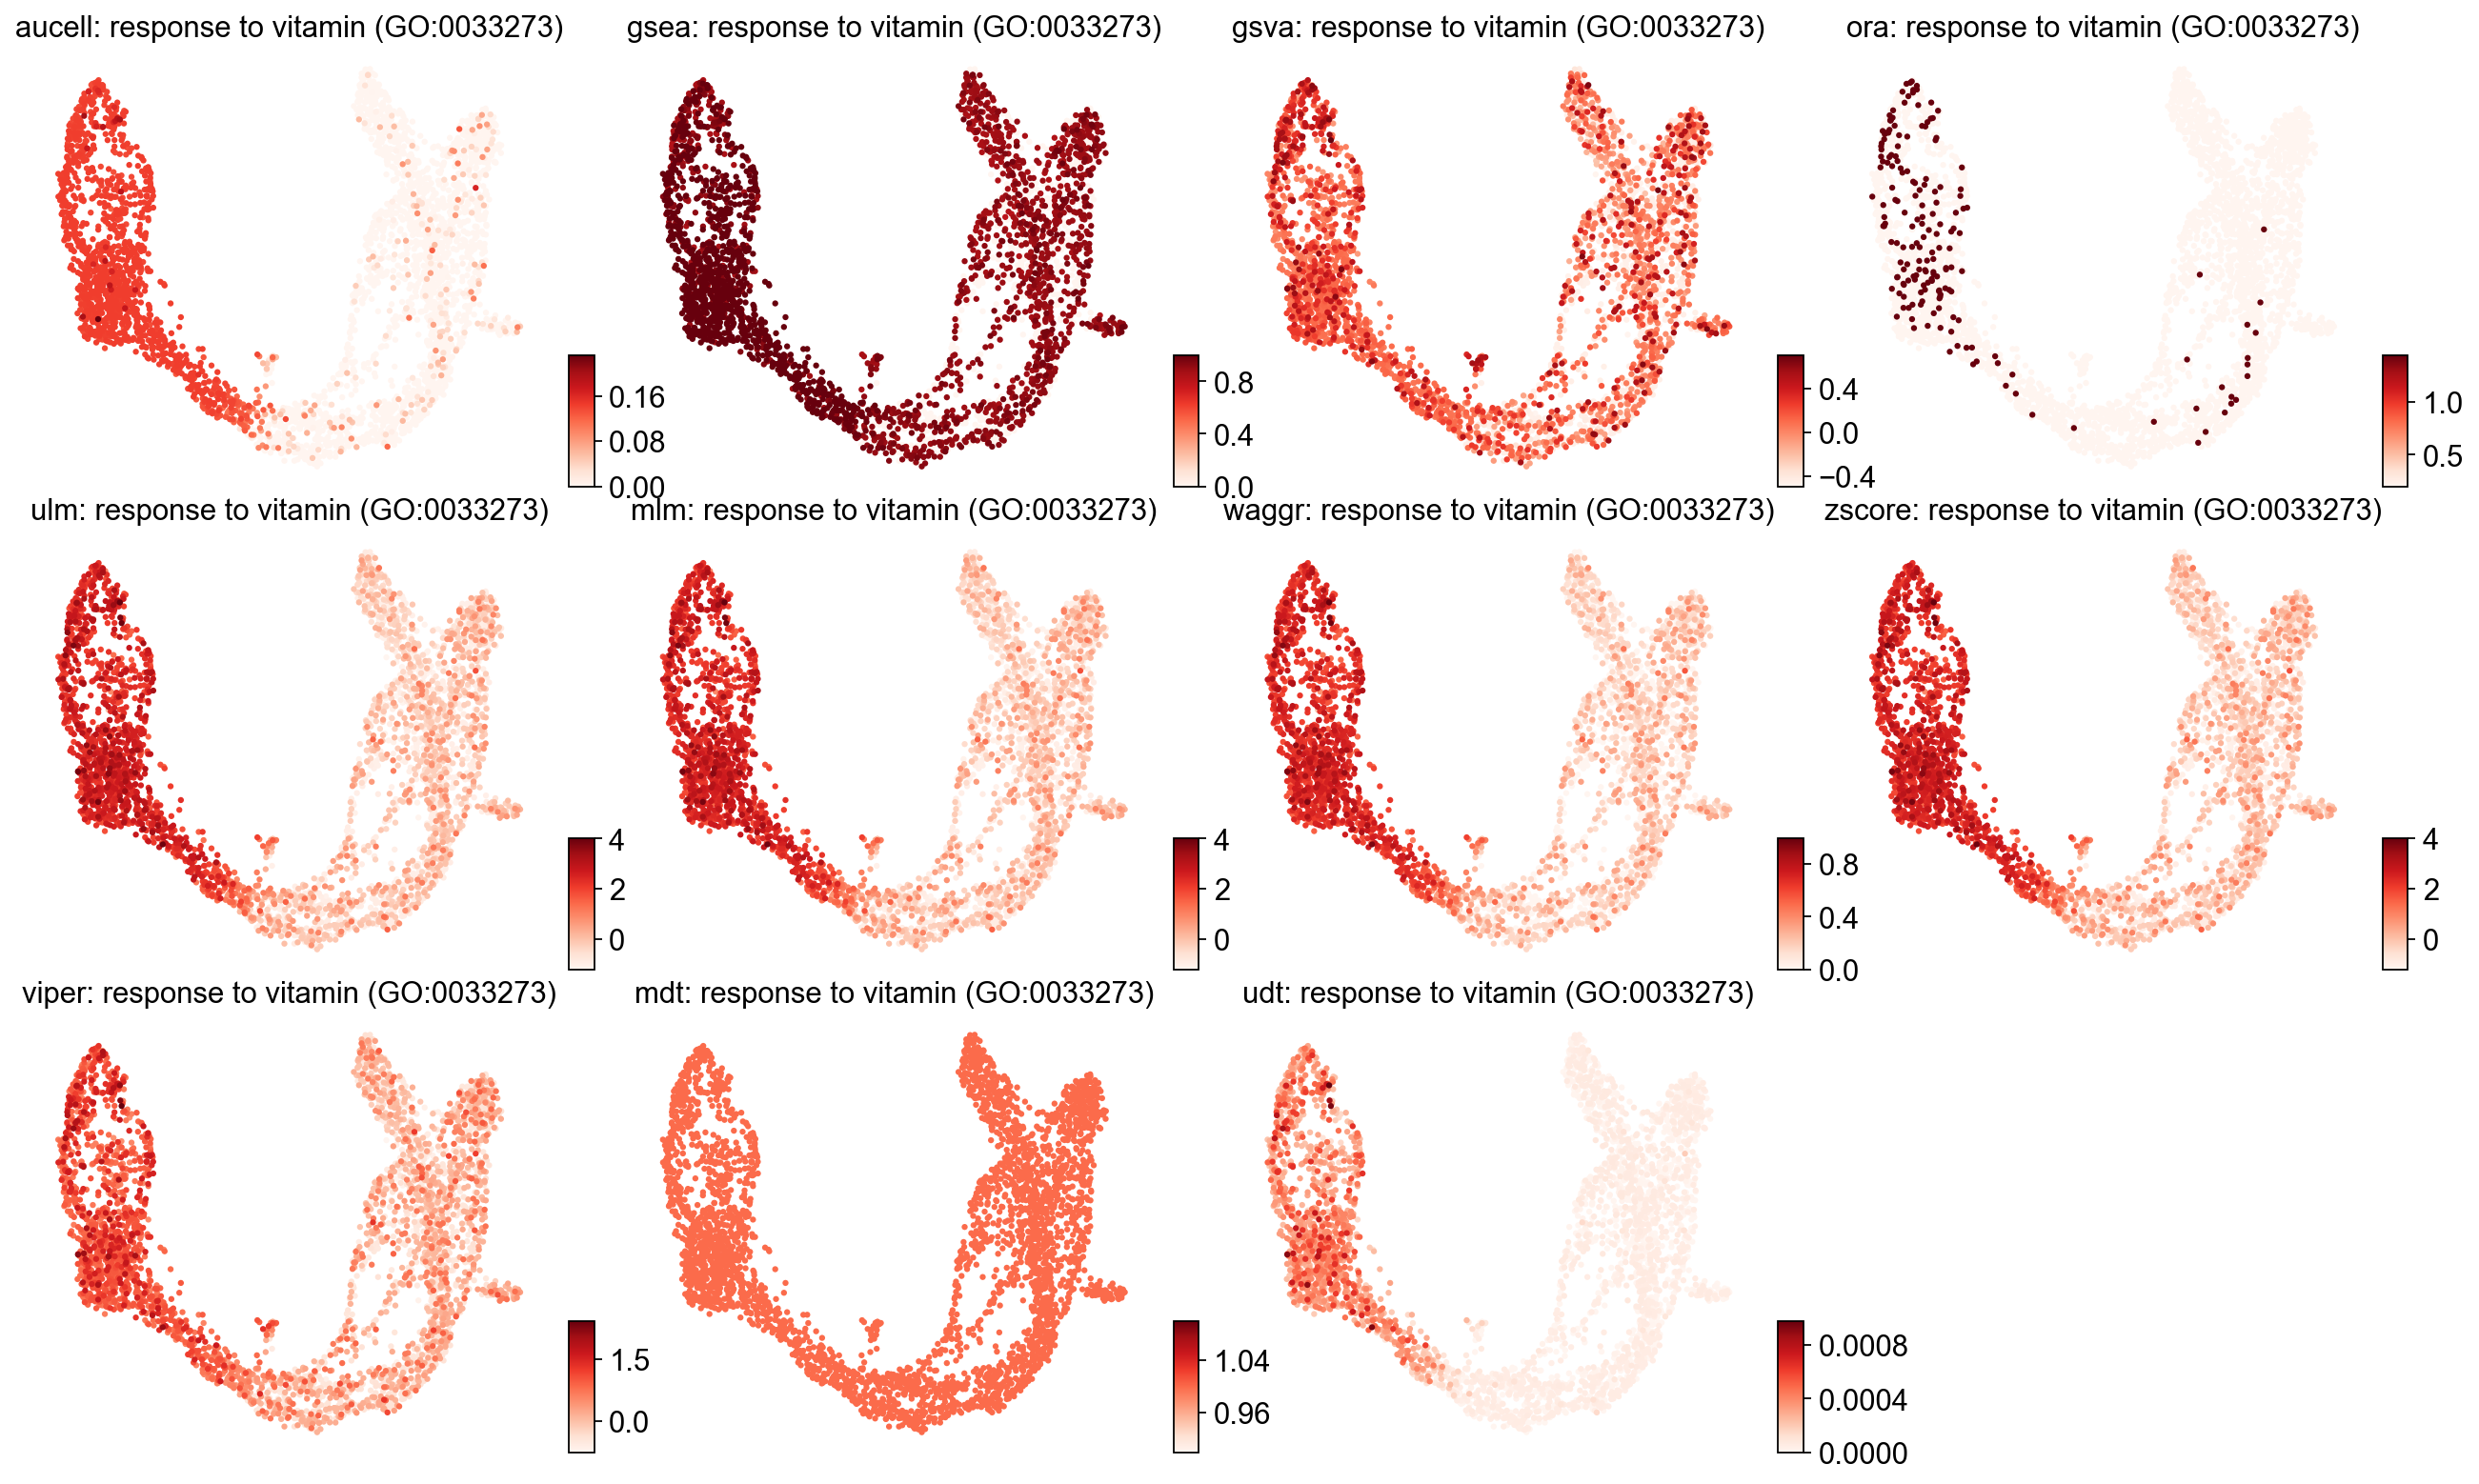

In [28]:
methods = ['aucell', 'gsea', 'gsva', 'ora', 'ulm', 'mlm',
           'waggr', 'zscore', 'viper', 'mdt', 'udt']
color = [f'{m}: {geneset_name}' for m in methods]
ov.pl.umap(adata, color=color, cmap='Reds', ncols=4, frameon=False)